# **CNN Melhorada**

## Principais diferenças em relação à implementação anterior:

- **Log-Mel Spectrograms** em vez de MFCCs (melhor para CNNs)
- **Arquitetura otimizada**: 3 camadas convolucionais (32, 64, 64 filtros)
- **Pooling assimétrico**: MaxPooling (3x3, 4x4, 4x4) para preservar informação temporal
- **Ativação ELU** em vez de ReLU
- **Data augmentation melhorada**: Additive Noise, Random Crop, Time Stretching
- **Dropout ajustado**: 0.1 nas camadas convolucionais, 0.3 nas densas


## Carregamento de bibliotecas


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')


/Users/gabrieltxc/Desktop/Home/Partilha/IACD/Ano3/Aprendizagem Computacional 2/Projeto1/audioml_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Parâmetros de Pré-processamento

Baseado no repositório de referência:
- **Sample Rate**: 22050 Hz
- **Mel Spectrogram**: 128 bandas, FFT 2048, Hop 512
- **Duração**: Variável (com padding/cropping)


In [2]:
SAMPLE_RATE = 22050
DURATION = 4
SAMPLES_PER_CLIP = int(SAMPLE_RATE * DURATION)

# Parâmetros para Mel Spectrogram (baseado no repositório)
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

print(f"Parâmetros configurados:")
print(f"  Sample Rate: {SAMPLE_RATE} Hz")
print(f"  Mel bands: {N_MELS}")
print(f"  FFT size: {N_FFT}")
print(f"  Hop length: {HOP_LENGTH}")


Parâmetros configurados:
  Sample Rate: 22050 Hz
  Mel bands: 128
  FFT size: 2048
  Hop length: 512


## Carregar Dataset


In [3]:
# Carregar dataset - usar caminho local
dataset_path = os.path.join(os.getcwd(), "UrbanSound8K")

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Diretório do dataset não encontrado: {dataset_path}")

metadata_path = os.path.join(dataset_path, "metadata", "UrbanSound8K.csv")
metadata = pd.read_csv(metadata_path)

def get_file_path(row):
    fold = f"fold{row['fold']}"
    file_name = row["slice_file_name"]
    return os.path.join(dataset_path, "audio", fold, file_name)

metadata["file_path"] = metadata.apply(get_file_path, axis=1)

print(f"Dataset carregado: {len(metadata)} amostras")
print(f"Classes: {len(metadata['class'].unique())}")


Dataset carregado: 8732 amostras
Classes: 10


## Funções de Pré-processamento

Baseadas no repositório de referência:
- **Mel Spectrogram** com normalização
- **Data Augmentation**: Additive Noise, Random Crop, Time Stretching


In [4]:
def load_audio(path, sr=SAMPLE_RATE):
    """Carrega áudio e normaliza"""
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y

def extract_mel_spectrogram(y, sr=SAMPLE_RATE, normalize=True):
    """
    Extrai Mel Spectrogram baseado no repositório de referência.
    Retorna espectrograma normalizado (whitened).
    """
    # Calcular Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmax=sr/2
    )
    
    # Converter para decibéis
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalização (whitening) - baseado no repositório
    if normalize:
        log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-8)
    
    return log_mel_spec

def augment_audio_additive_noise(y, prob=0.3, sig=0.001):
    """Adiciona ruído gaussiano (baseado no repositório)"""
    if np.random.rand() < prob:
        noise = np.random.normal(0, sig, len(y))
        y = y + noise
    return y

def augment_audio_random_crop(y, prob=0.4, sig=0.25):
    """Random crop com distribuição half-normal (baseado no repositório)"""
    if np.random.rand() < prob:
        # Calcular comprimento do crop (half-normal distribution)
        crop_length = int(len(y) * (1 - abs(np.random.normal(0, sig))))
        crop_length = max(crop_length, int(len(y) * 0.5))  # Mínimo 50% do áudio
        
        if crop_length < len(y):
            start = np.random.randint(0, len(y) - crop_length + 1)
            y = y[start:start + crop_length]
            # Padding para manter comprimento original
            if len(y) < SAMPLES_PER_CLIP:
                y = np.pad(y, (0, SAMPLES_PER_CLIP - len(y)), mode='constant')
    return y

def augment_audio_time_stretch(y, sr=SAMPLE_RATE, prob=0.3):
    """Time stretching usando phase vocoder (baseado no repositório)"""
    if np.random.rand() < prob:
        rate = np.random.uniform(0.8, 1.2)
        y = librosa.effects.time_stretch(y, rate=rate)
    return y

# Testar funções
test_path = metadata.iloc[0]["file_path"]
test_audio = load_audio(test_path)
test_spec = extract_mel_spectrogram(test_audio)
print(f"Shape do Mel Spectrogram: {test_spec.shape}")
print(f"Valores min/max: {test_spec.min():.4f} / {test_spec.max():.4f}")


Shape do Mel Spectrogram: (128, 14)
Valores min/max: -1.9543 / 2.3098


## Extrair e Salvar Mel Spectrograms

Processamos todos os áudios e geramos os Mel Spectrograms com data augmentation.


In [5]:
PROCESSED_DIR = "processed_data"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Verificar se já existem dados processados
spec_file = os.path.join(PROCESSED_DIR, "X_cnn_mel_improved.npy")
labels_file = os.path.join(PROCESSED_DIR, "y_labels_cnn_improved.npy")
folds_file = os.path.join(PROCESSED_DIR, "folds_cnn_improved.npy")

if os.path.exists(spec_file) and os.path.exists(labels_file) and os.path.exists(folds_file):
    print("Carregando dados pré-processados existentes...")
    X_cnn = np.load(spec_file)
    y = np.load(labels_file)
    folds = np.load(folds_file)
    print(f"Dados carregados: X shape = {X_cnn.shape}, y shape = {y.shape}")
else:
    print("Processando áudios e extraindo Mel Spectrograms...")
    X_cnn_list = []
    y_list = []
    fold_list = []
    
    for idx, row in metadata.iterrows():
        if (idx + 1) % 100 == 0:
            print(f"Processando {idx + 1}/{len(metadata)}...")
        
        file_path = row["file_path"]
        label = row["classID"]
        fold = row["fold"]
        
        # Áudio original
        y_audio = load_audio(file_path)
        
        # Garantir duração mínima
        if len(y_audio) < SAMPLES_PER_CLIP:
            y_audio = np.pad(y_audio, (0, SAMPLES_PER_CLIP - len(y_audio)), mode='constant')
        elif len(y_audio) > SAMPLES_PER_CLIP:
            y_audio = y_audio[:SAMPLES_PER_CLIP]
        
        spec_orig = extract_mel_spectrogram(y_audio)
        X_cnn_list.append(spec_orig)
        y_list.append(label)
        fold_list.append(fold)
        
        # Áudios aumentados (3 versões)
        # Versão 1: Additive Noise
        y_aug1 = augment_audio_additive_noise(y_audio.copy(), prob=1.0, sig=0.001)
        if len(y_aug1) != SAMPLES_PER_CLIP:
            if len(y_aug1) < SAMPLES_PER_CLIP:
                y_aug1 = np.pad(y_aug1, (0, SAMPLES_PER_CLIP - len(y_aug1)), mode='constant')
            else:
                y_aug1 = y_aug1[:SAMPLES_PER_CLIP]
        spec_aug1 = extract_mel_spectrogram(y_aug1)
        X_cnn_list.append(spec_aug1)
        y_list.append(label)
        fold_list.append(fold)
        
        # Versão 2: Random Crop
        y_aug2 = augment_audio_random_crop(y_audio.copy(), prob=1.0, sig=0.25)
        if len(y_aug2) != SAMPLES_PER_CLIP:
            if len(y_aug2) < SAMPLES_PER_CLIP:
                y_aug2 = np.pad(y_aug2, (0, SAMPLES_PER_CLIP - len(y_aug2)), mode='constant')
            else:
                y_aug2 = y_aug2[:SAMPLES_PER_CLIP]
        spec_aug2 = extract_mel_spectrogram(y_aug2)
        X_cnn_list.append(spec_aug2)
        y_list.append(label)
        fold_list.append(fold)
        
        # Versão 3: Time Stretch
        y_aug3 = augment_audio_time_stretch(y_audio.copy(), prob=1.0)
        if len(y_aug3) != SAMPLES_PER_CLIP:
            if len(y_aug3) < SAMPLES_PER_CLIP:
                y_aug3 = np.pad(y_aug3, (0, SAMPLES_PER_CLIP - len(y_aug3)), mode='constant')
            else:
                y_aug3 = y_aug3[:SAMPLES_PER_CLIP]
        spec_aug3 = extract_mel_spectrogram(y_aug3)
        X_cnn_list.append(spec_aug3)
        y_list.append(label)
        fold_list.append(fold)
    
    X_cnn = np.array(X_cnn_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    folds = np.array(fold_list, dtype=np.int64)
    
    # Adicionar dimensão de canal para CNN (batch, height, width, channels)
    X_cnn = np.expand_dims(X_cnn, axis=-1)  # Shape: (n_samples, n_mels, time_frames, 1)
    
    # Salvar
    np.save(spec_file, X_cnn)
    np.save(labels_file, y)
    np.save(folds_file, folds)
    
    print(f"Processamento concluído!")
    print(f"X_cnn shape: {X_cnn.shape}")
    print(f"y shape: {y.shape}")
    print(f"folds shape: {folds.shape}")

n_classes = len(np.unique(y))
print(f"\nNúmero de classes: {n_classes}")


Processando áudios e extraindo Mel Spectrograms...
Processando 100/8732...
Processando 200/8732...
Processando 300/8732...
Processando 400/8732...
Processando 500/8732...
Processando 600/8732...
Processando 700/8732...
Processando 800/8732...
Processando 900/8732...
Processando 1000/8732...
Processando 1100/8732...
Processando 1200/8732...
Processando 1300/8732...
Processando 1400/8732...
Processando 1500/8732...
Processando 1600/8732...
Processando 1700/8732...
Processando 1800/8732...
Processando 1900/8732...
Processando 2000/8732...
Processando 2100/8732...
Processando 2200/8732...
Processando 2300/8732...
Processando 2400/8732...
Processando 2500/8732...
Processando 2600/8732...
Processando 2700/8732...
Processando 2800/8732...
Processando 2900/8732...
Processando 3000/8732...
Processando 3100/8732...
Processando 3200/8732...
Processando 3300/8732...
Processando 3400/8732...
Processando 3500/8732...
Processando 3600/8732...
Processando 3700/8732...
Processando 3800/8732...
Processa

## Arquitetura CNN

- **3 camadas convolucionais**: 32, 64, 64 filtros
- **MaxPooling assimétrico**: (3,3), (4,4), (4,4)
- **Ativação ELU** (em vez de ReLU)
- **Dropout**: 0.1 nas convolucionais, 0.3 nas densas
- **Batch Normalization** após cada convolução


In [6]:
def build_cnn_improved_model(input_shape, n_classes, dropout_conv=0.1, dropout_dense=0.3, learning_rate=1e-3, l2_reg=1e-4):
    """
    Constrói CNN baseada no repositório de referência.
    
    Args:
        input_shape: Shape da entrada (height, width, channels)
        n_classes: Número de classes
        dropout_conv: Dropout nas camadas convolucionais
        dropout_dense: Dropout nas camadas densas
        learning_rate: Taxa de aprendizagem
        l2_reg: Regularização L2
    
    Returns:
        Modelo compilado
    """
    inputs = layers.Input(shape=input_shape)
    
    # Conv Block 1: 32 filtros
    x = layers.Conv2D(32, (3, 3), padding='valid', 
                      kernel_regularizer=l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)  # ELU em vez de ReLU (baseado no repositório)
    x = layers.MaxPooling2D((3, 3))(x)  # Pooling 3x3
    x = layers.Dropout(dropout_conv)(x)
    
    # Conv Block 2: 64 filtros
    x = layers.Conv2D(64, (3, 3), padding='valid',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D((4, 4))(x)  # Pooling 4x4
    x = layers.Dropout(dropout_conv)(x)
    
    # Conv Block 3: 64 filtros
    x = layers.Conv2D(64, (3, 3), padding='valid',
                      kernel_regularizer=l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D((4, 4))(x)  # Pooling 4x4
    x = layers.Dropout(dropout_conv)(x)
    
    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Classificador
    x = layers.Dropout(dropout_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(n_classes, activation='softmax', 
                     kernel_regularizer=l2(l2_reg))(x)
    
    model = models.Model(inputs=inputs, outputs=x)
    
    # Compilar
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Determinar input shape
input_shape = (X_cnn.shape[1], X_cnn.shape[2], X_cnn.shape[3])
print(f"Input shape: {input_shape}")

# Criar modelo
model = build_cnn_improved_model(input_shape, n_classes)
model.summary()


Input shape: (128, 173, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 173, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 171, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 171, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu (ELU)                       │ (None, 126, 171, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 42, 57, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 55, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 55, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_1 (ELU)                     │ (None, 40, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 11, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 11, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ elu_2 (ELU)                     │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,290 (223.79 KB)

 Trainable params: 56,842 (222.04 KB)

 Non-trainable params: 448 (1.75 KB)

## Hiperparâmetros e Callbacks


In [7]:
learning_rate = 1e-3
batch_size = 32
epochs = 50

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

callback_list = [early_stop, reduce_lr]


## Treino com Validação Cruzada de 10 Folds


In [8]:
class_names = ["air-conditioner", "car-horn", "children-playing", "dog-bark", 
               "drilling", "engine-idling", "gun-shot", "jackhammer", 
               "siren", "street-music"]

def plot_graphs(history, y_true, y_pred, class_labels):
    """Visualiza métricas de treino e matriz de confusão"""
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)

    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=axs[2])
    axs[2].set_title('Confusion Matrix')
    axs[2].set_xlabel('Predicted')
    axs[2].set_ylabel('True')
    plt.setp(axs[2].get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()



=== Training Fold 1 (Validation Fold 2) ===
Train samples: 27884
Validation samples: 3552
Test samples: 3492
Epoch 1/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 55s 61ms/step - accuracy: 0.4050 - loss: 1.7390 - val_accuracy: 0.5327 - val_loss: 1.2225 - learning_rate: 0.0010
Epoch 2/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.6786 - loss: 0.9774 - val_accuracy: 0.5096 - val_loss: 1.3206 - learning_rate: 0.0010
Epoch 3/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7435 - loss: 0.8010 - val_accuracy: 0.6616 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 4/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7680 - loss: 0.7133 - val_accuracy: 0.5366 - val_loss: 1.5416 - learning_rate: 0.0010
Epoch 5/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7963 - loss: 0.6541 - val_accuracy: 0.6075 - val_loss: 1.2853 - learning_rate: 0.0010
Epoch 6/50
871/872 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8115 - loss: 0.6032
Epoch 6: ReduceLROnPlateau reduci

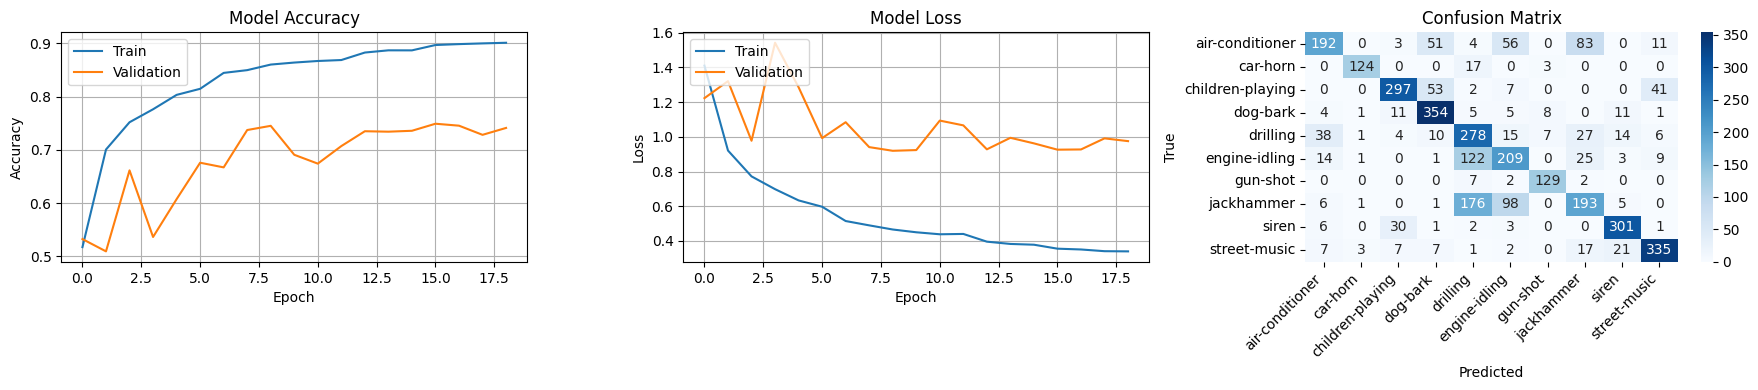


=== Training Fold 2 (Validation Fold 3) ===
Train samples: 27676
Validation samples: 3700
Test samples: 3552
Epoch 1/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.4202 - loss: 1.6857 - val_accuracy: 0.5535 - val_loss: 1.2968 - learning_rate: 0.0010
Epoch 2/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.6899 - loss: 0.9671 - val_accuracy: 0.5543 - val_loss: 1.3693 - learning_rate: 0.0010
Epoch 3/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.7523 - loss: 0.7775 - val_accuracy: 0.5716 - val_loss: 1.2816 - learning_rate: 0.0010
Epoch 4/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.7882 - loss: 0.6788 - val_accuracy: 0.5959 - val_loss: 1.1284 - learning_rate: 0.0010
Epoch 5/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.8039 - loss: 0.6378 - val_accuracy: 0.6135 - val_loss: 1.2338 - learning_rate: 0.0010
Epoch 6/50
865/865 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.8155 - loss: 0.5886 - val_accuracy: 0.6508 - val_los

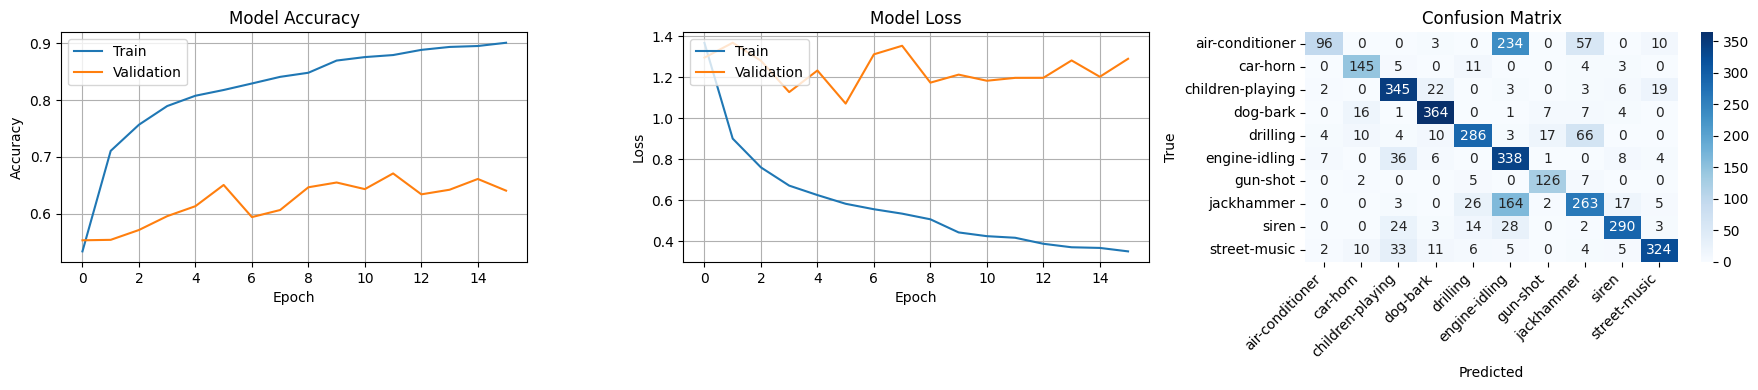


=== Training Fold 3 (Validation Fold 4) ===
Train samples: 27268
Validation samples: 3960
Test samples: 3700
Epoch 1/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.4241 - loss: 1.7014 - val_accuracy: 0.6230 - val_loss: 1.2324 - learning_rate: 0.0010
Epoch 2/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.6802 - loss: 0.9718 - val_accuracy: 0.5929 - val_loss: 1.1711 - learning_rate: 0.0010
Epoch 3/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7355 - loss: 0.8278 - val_accuracy: 0.6533 - val_loss: 1.0828 - learning_rate: 0.0010
Epoch 4/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7743 - loss: 0.7052 - val_accuracy: 0.6124 - val_loss: 1.1449 - learning_rate: 0.0010
Epoch 5/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.7975 - loss: 0.6489 - val_accuracy: 0.6407 - val_loss: 1.1686 - learning_rate: 0.0010
Epoch 6/50
853/853 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.8150 - loss: 0.5950 - val_accuracy: 0.6503 - val_los

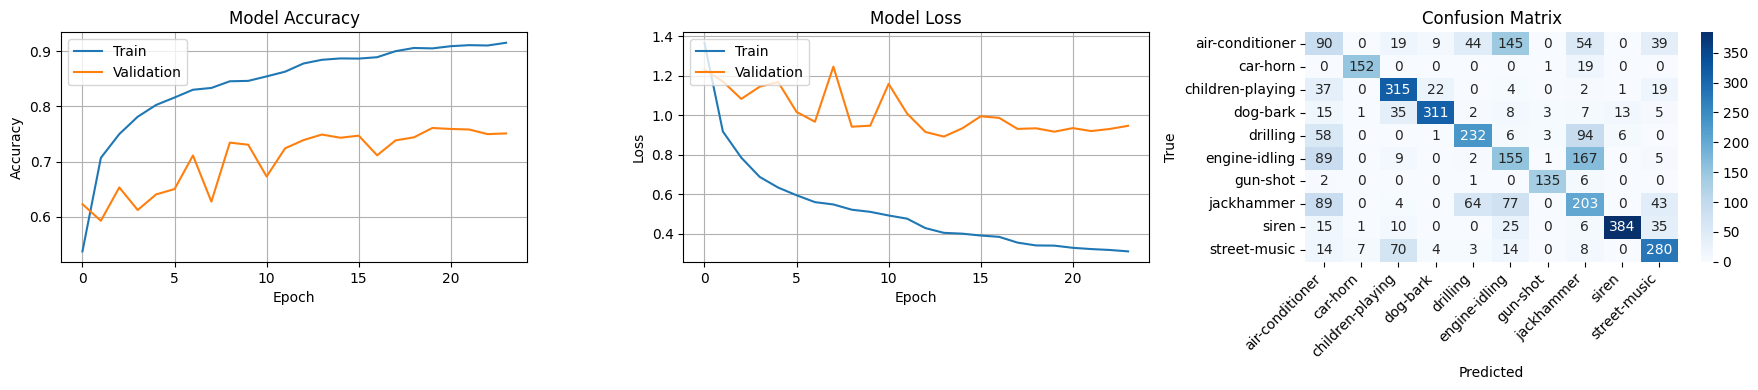


=== Training Fold 4 (Validation Fold 5) ===
Train samples: 27224
Validation samples: 3744
Test samples: 3960
Epoch 1/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.4044 - loss: 1.7412 - val_accuracy: 0.6146 - val_loss: 1.1697 - learning_rate: 0.0010
Epoch 2/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - accuracy: 0.6613 - loss: 1.0144 - val_accuracy: 0.5996 - val_loss: 1.1370 - learning_rate: 0.0010
Epoch 3/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.7361 - loss: 0.8149 - val_accuracy: 0.6779 - val_loss: 0.9614 - learning_rate: 0.0010
Epoch 4/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.7731 - loss: 0.7100 - val_accuracy: 0.6480 - val_loss: 1.0463 - learning_rate: 0.0010
Epoch 5/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.7989 - loss: 0.6409 - val_accuracy: 0.7639 - val_loss: 0.8238 - learning_rate: 0.0010
Epoch 6/50
851/851 ━━━━━━━━━━━━━━━━━━━━ 51s 60ms/step - accuracy: 0.8186 - loss: 0.5968 - val_accuracy: 0.7706 - val_los

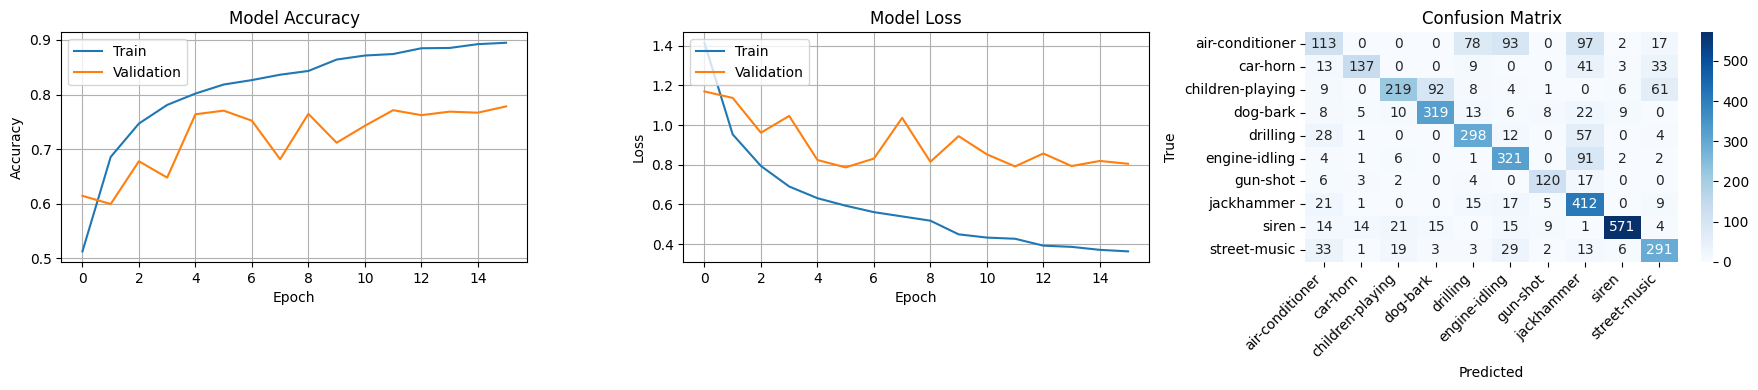


=== Training Fold 5 (Validation Fold 6) ===
Train samples: 27892
Validation samples: 3292
Test samples: 3744
Epoch 1/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - accuracy: 0.4172 - loss: 1.6945 - val_accuracy: 0.4596 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.6780 - loss: 0.9924 - val_accuracy: 0.5778 - val_loss: 1.2349 - learning_rate: 0.0010
Epoch 3/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - accuracy: 0.7368 - loss: 0.8028 - val_accuracy: 0.6097 - val_loss: 1.1515 - learning_rate: 0.0010
Epoch 4/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.7722 - loss: 0.7097 - val_accuracy: 0.6163 - val_loss: 1.1905 - learning_rate: 0.0010
Epoch 5/50
872/872 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.8018 - loss: 0.6403 - val_accuracy: 0.6425 - val_loss: 1.1841 - learning_rate: 0.0010
Epoch 6/50
871/872 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8109 - loss: 0.5971
Epoch 6: ReduceLROnPlateau reduci

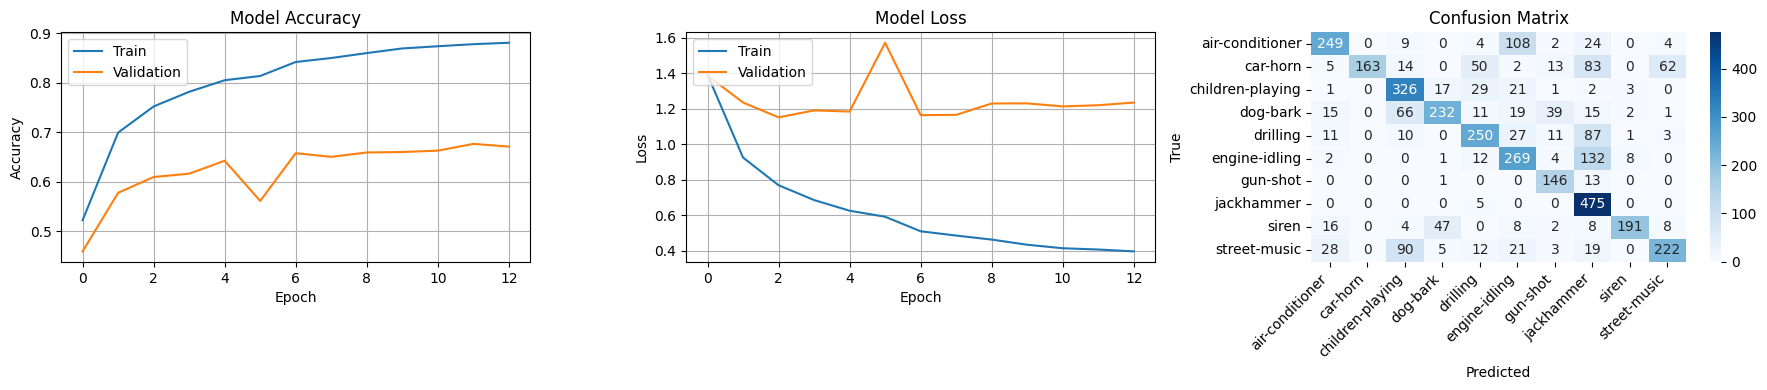


=== Training Fold 6 (Validation Fold 7) ===
Train samples: 28284
Validation samples: 3352
Test samples: 3292
Epoch 1/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 55s 61ms/step - accuracy: 0.4229 - loss: 1.6868 - val_accuracy: 0.4541 - val_loss: 1.5402 - learning_rate: 0.0010
Epoch 2/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.6910 - loss: 0.9621 - val_accuracy: 0.6050 - val_loss: 1.1247 - learning_rate: 0.0010
Epoch 3/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7520 - loss: 0.7823 - val_accuracy: 0.6041 - val_loss: 1.2746 - learning_rate: 0.0010
Epoch 4/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7843 - loss: 0.6936 - val_accuracy: 0.6229 - val_loss: 1.1767 - learning_rate: 0.0010
Epoch 5/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.8006 - loss: 0.6464 - val_accuracy: 0.6125 - val_loss: 1.1128 - learning_rate: 0.0010
Epoch 6/50
884/884 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.8145 - loss: 0.5928 - val_accuracy: 0.6724 - val_los

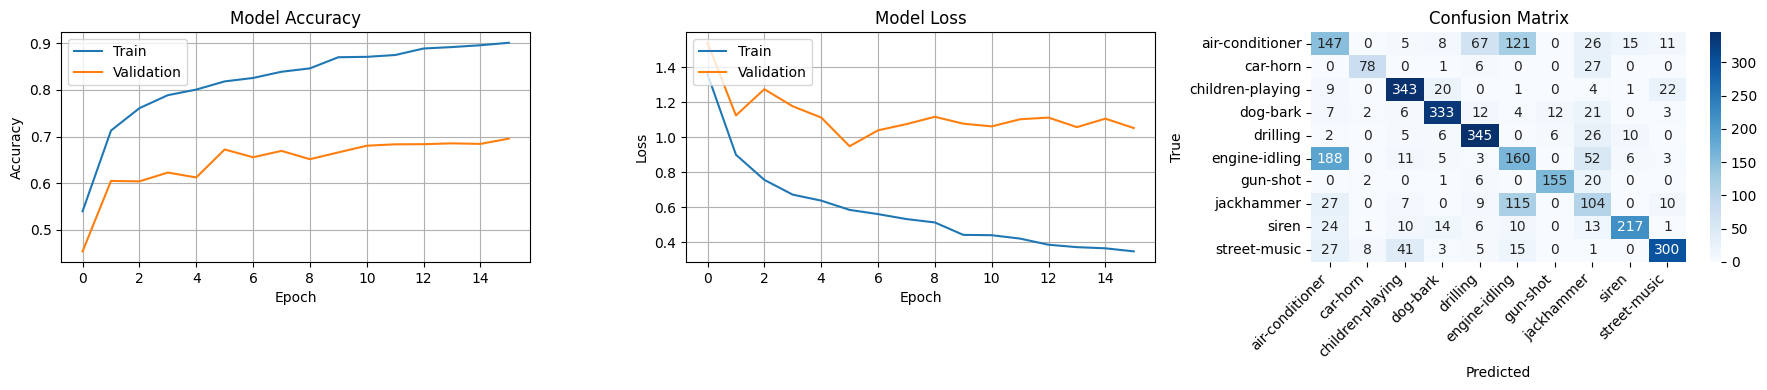


=== Training Fold 7 (Validation Fold 8) ===
Train samples: 28352
Validation samples: 3224
Test samples: 3352
Epoch 1/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 56s 62ms/step - accuracy: 0.4133 - loss: 1.7173 - val_accuracy: 0.5583 - val_loss: 1.3959 - learning_rate: 0.0010
Epoch 2/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.6964 - loss: 0.9332 - val_accuracy: 0.5788 - val_loss: 1.3072 - learning_rate: 0.0010
Epoch 3/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.7583 - loss: 0.7683 - val_accuracy: 0.6086 - val_loss: 1.4223 - learning_rate: 0.0010
Epoch 4/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7845 - loss: 0.6792 - val_accuracy: 0.5937 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 5/50
886/886 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8083 - loss: 0.6229
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
886/886 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.8083 - loss: 0.6229 - val_accuracy: 0.6197 - val_loss:

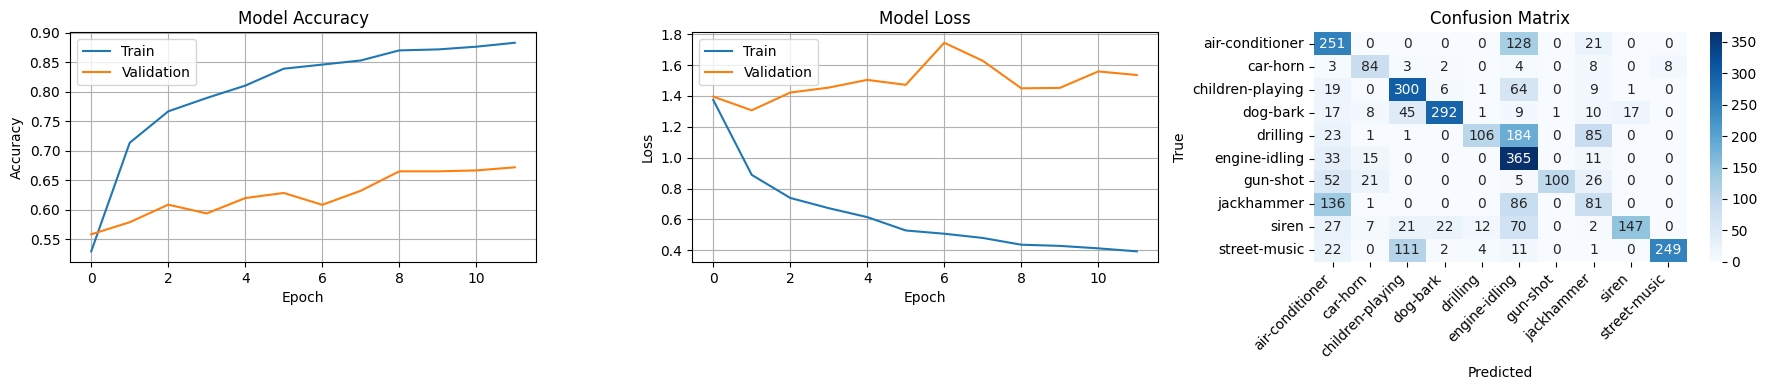


=== Training Fold 8 (Validation Fold 9) ===
Train samples: 28440
Validation samples: 3264
Test samples: 3224
Epoch 1/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 54s 59ms/step - accuracy: 0.4032 - loss: 1.7495 - val_accuracy: 0.5536 - val_loss: 1.2997 - learning_rate: 0.0010
Epoch 2/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.6757 - loss: 0.9835 - val_accuracy: 0.6005 - val_loss: 1.3712 - learning_rate: 0.0010
Epoch 3/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.7452 - loss: 0.7891 - val_accuracy: 0.7001 - val_loss: 1.0944 - learning_rate: 0.0010
Epoch 4/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.7754 - loss: 0.7093 - val_accuracy: 0.7356 - val_loss: 0.9756 - learning_rate: 0.0010
Epoch 5/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - accuracy: 0.8005 - loss: 0.6495 - val_accuracy: 0.7267 - val_loss: 1.0127 - learning_rate: 0.0010
Epoch 6/50
889/889 ━━━━━━━━━━━━━━━━━━━━ 53s 59ms/step - accuracy: 0.8108 - loss: 0.6102 - val_accuracy: 0.7166 - val_los

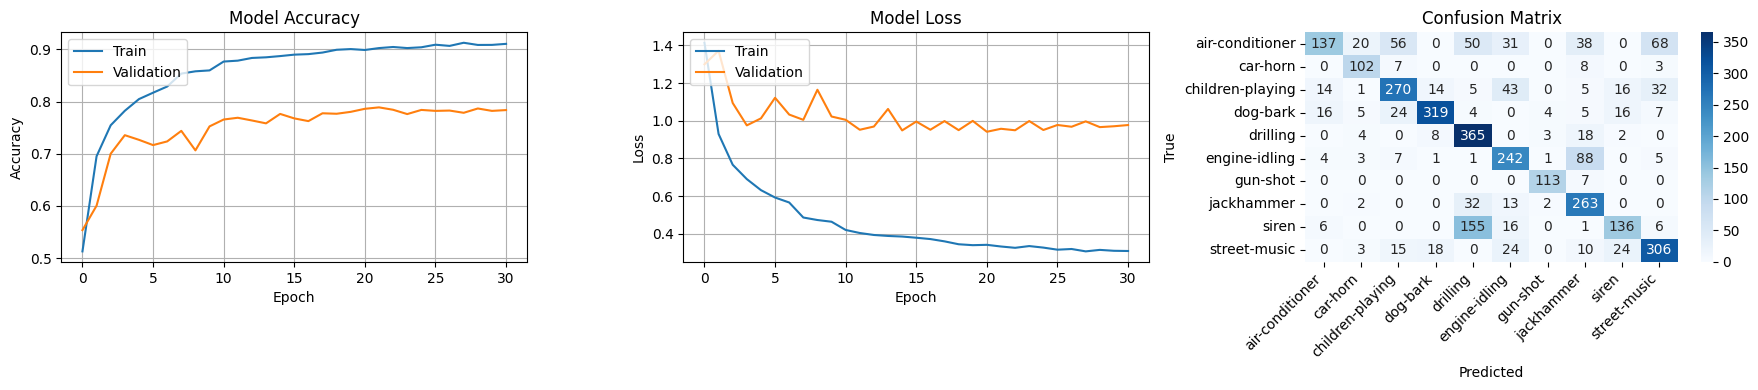


=== Training Fold 9 (Validation Fold 10) ===
Train samples: 28316
Validation samples: 3348
Test samples: 3264
Epoch 1/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 54s 59ms/step - accuracy: 0.4004 - loss: 1.7285 - val_accuracy: 0.5836 - val_loss: 1.1656 - learning_rate: 0.0010
Epoch 2/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.6721 - loss: 0.9928 - val_accuracy: 0.6676 - val_loss: 1.0922 - learning_rate: 0.0010
Epoch 3/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 55s 62ms/step - accuracy: 0.7436 - loss: 0.8100 - val_accuracy: 0.7064 - val_loss: 0.8544 - learning_rate: 0.0010
Epoch 4/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.7749 - loss: 0.7221 - val_accuracy: 0.6243 - val_loss: 1.0965 - learning_rate: 0.0010
Epoch 5/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.7974 - loss: 0.6520 - val_accuracy: 0.7046 - val_loss: 0.9297 - learning_rate: 0.0010
Epoch 6/50
885/885 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8112 - loss: 0.6135
Epoch 6: ReduceLROnPlateau reduc

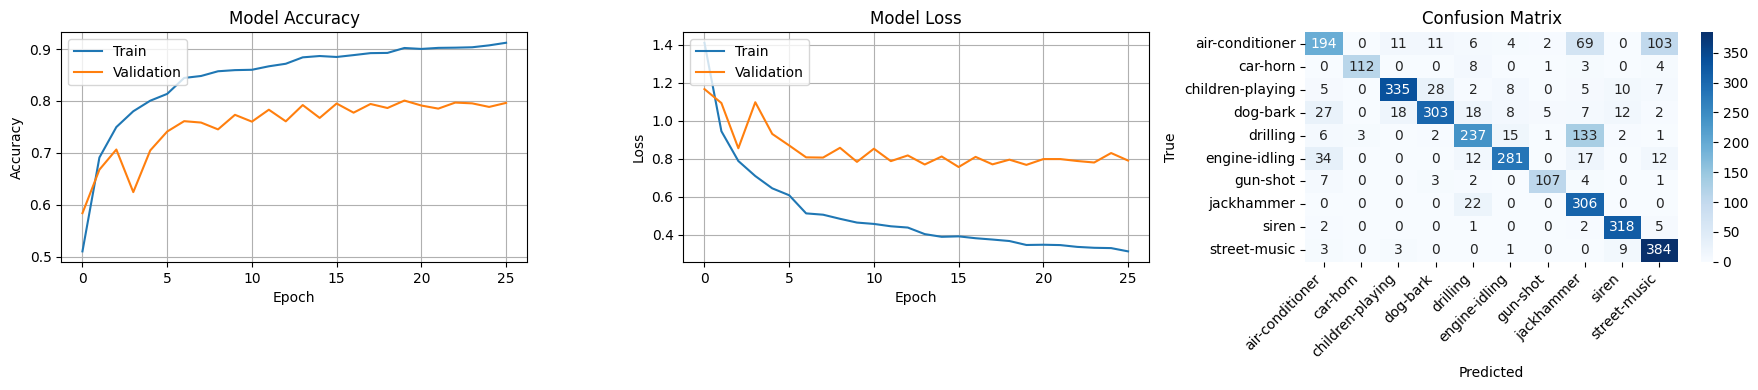


=== Training Fold 10 (Validation Fold 1) ===
Train samples: 28088
Validation samples: 3492
Test samples: 3348
Epoch 1/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 54s 60ms/step - accuracy: 0.3983 - loss: 1.7415 - val_accuracy: 0.5753 - val_loss: 1.2112 - learning_rate: 0.0010
Epoch 2/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.6761 - loss: 0.9863 - val_accuracy: 0.6200 - val_loss: 1.2393 - learning_rate: 0.0010
Epoch 3/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.7467 - loss: 0.7988 - val_accuracy: 0.6317 - val_loss: 1.1741 - learning_rate: 0.0010
Epoch 4/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.7799 - loss: 0.6974 - val_accuracy: 0.6578 - val_loss: 1.2165 - learning_rate: 0.0010
Epoch 5/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.7984 - loss: 0.6479 - val_accuracy: 0.6561 - val_loss: 1.1243 - learning_rate: 0.0010
Epoch 6/50
878/878 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.8151 - loss: 0.5950 - val_accuracy: 0.6813 - val_lo

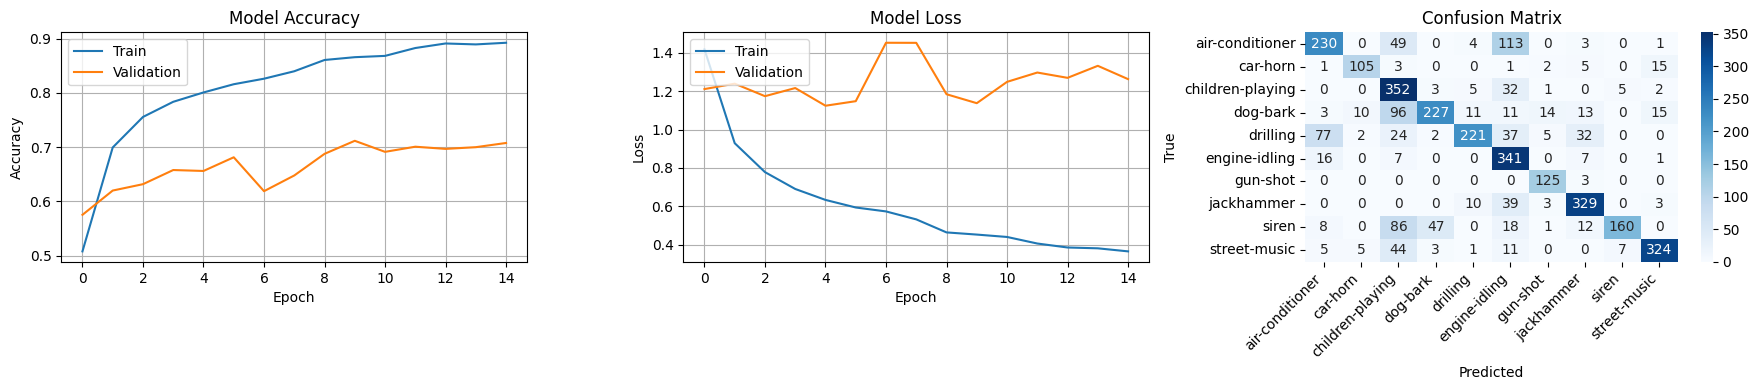


RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION
Fold accuracies: ['0.6907', '0.7255', '0.6100', '0.7073', '0.6739', '0.6628', '0.5892', '0.6988', '0.7895', '0.7210']
Mean accuracy: 0.6869 ± 0.0547
Target (repositório): 71.0%


In [9]:
# Inicializar variáveis para armazenar resultados
y_true_all = []
y_pred_all = []
conf_mat = np.zeros((n_classes, n_classes), dtype=np.int64)
fold_accuracies = []
fold_histories = []

# 10-fold cross-validation
for test_fold in range(1, 11):
    val_fold = (test_fold % 10) + 1
    
    # Divisão dos dados
    train_idx = np.where((folds != test_fold) & (folds != val_fold))[0]
    val_idx = np.where(folds == val_fold)[0]
    test_idx = np.where(folds == test_fold)[0]
    
    X_train = X_cnn[train_idx]
    X_val = X_cnn[val_idx]
    X_test = X_cnn[test_idx]
    
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    
    # Criar modelo
    model = build_cnn_improved_model(
        input_shape=input_shape,
        n_classes=n_classes,
        dropout_conv=0.1,
        dropout_dense=0.3,
        learning_rate=learning_rate
    )
    
    print(f"\n{'='*60}")
    print(f"=== Training Fold {test_fold} (Validation Fold {val_fold}) ===")
    print(f"{'='*60}")
    print(f"Train samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    
    # Treinar
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callback_list,
        verbose=1
    )
    
    fold_histories.append(history.history)
    
    # Avaliar no conjunto de teste
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    fold_acc = np.mean(y_pred == y_test)
    fold_accuracies.append(fold_acc)
    print(f"\nFold {test_fold} Test Accuracy: {fold_acc:.4f}")
    
    # Atualizar matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
    conf_mat += cm
    
    # Armazenar predições
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred.tolist())
    
    # Visualizar resultados do fold
    plot_graphs(history, y_test, y_pred, class_names)

# Resultados finais
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\n{'='*60}")
print("RESULTADOS FINAIS - 10-FOLD CROSS-VALIDATION")
print(f"{'='*60}")
print(f"Fold accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")
print(f"Mean accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Target (repositório): 71.0%")
print(f"{'='*60}")


## Matriz de Confusão Global e Métricas por Classe


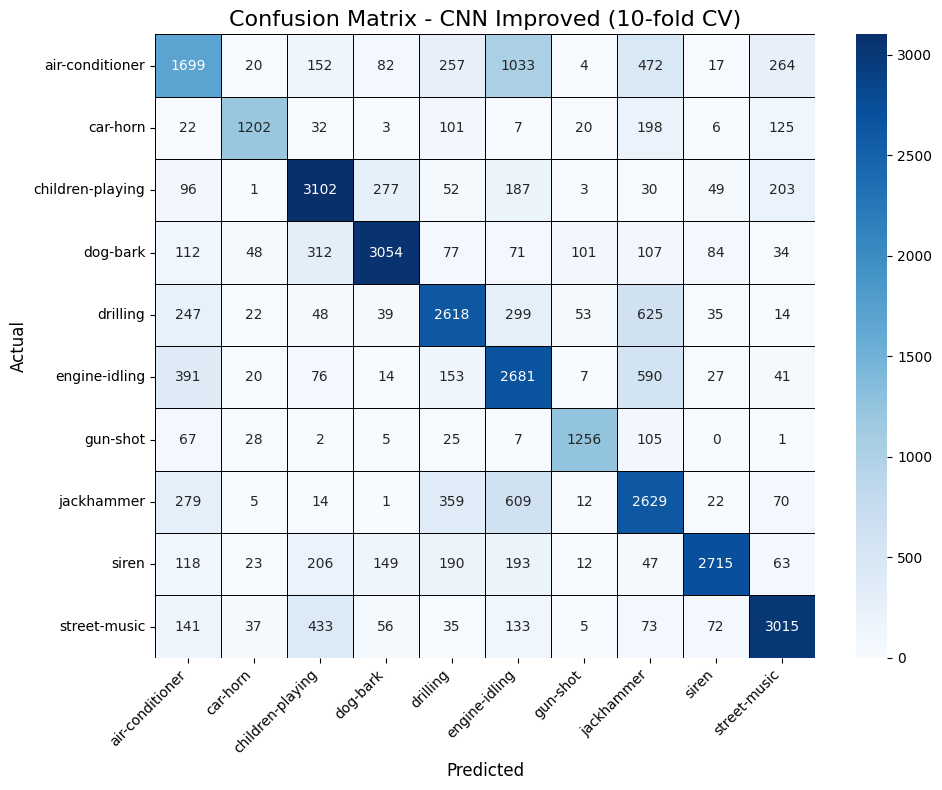


Métricas por Classe:
           Class  Precision   Recall       F1  Support
 air-conditioner   0.535624 0.424750 0.473787     4000
        car-horn   0.854908 0.700466 0.770019     1716
children-playing   0.708705 0.775500 0.740599     4000
        dog-bark   0.829891 0.763500 0.795312     4000
        drilling   0.677011 0.654500 0.665565     4000
   engine-idling   0.513602 0.670250 0.581562     4000
        gun-shot   0.852682 0.839572 0.846076     1496
      jackhammer   0.539171 0.657250 0.592384     4000
           siren   0.896928 0.730624 0.805280     3716
    street-music   0.787206 0.753750 0.770115     4000
   Macro-average   0.719573 0.697016 0.704070    34928


In [18]:
# Matriz de confusão global
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="black"
)
plt.title("Confusion Matrix - CNN Improved (10-fold CV)", fontsize=16)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Métricas por classe
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true_all,
    y_pred_all,
    labels=np.arange(n_classes),
    average=None
)

macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

df_metrics.loc[len(df_metrics)] = [
    "Macro-average", 
    macro_precision, 
    macro_recall, 
    macro_f1,
    len(y_true_all)
]

print("\nMétricas por Classe:")
print(df_metrics.to_string(index=False))


## Curvas de Aprendizagem (Média sobre Folds)


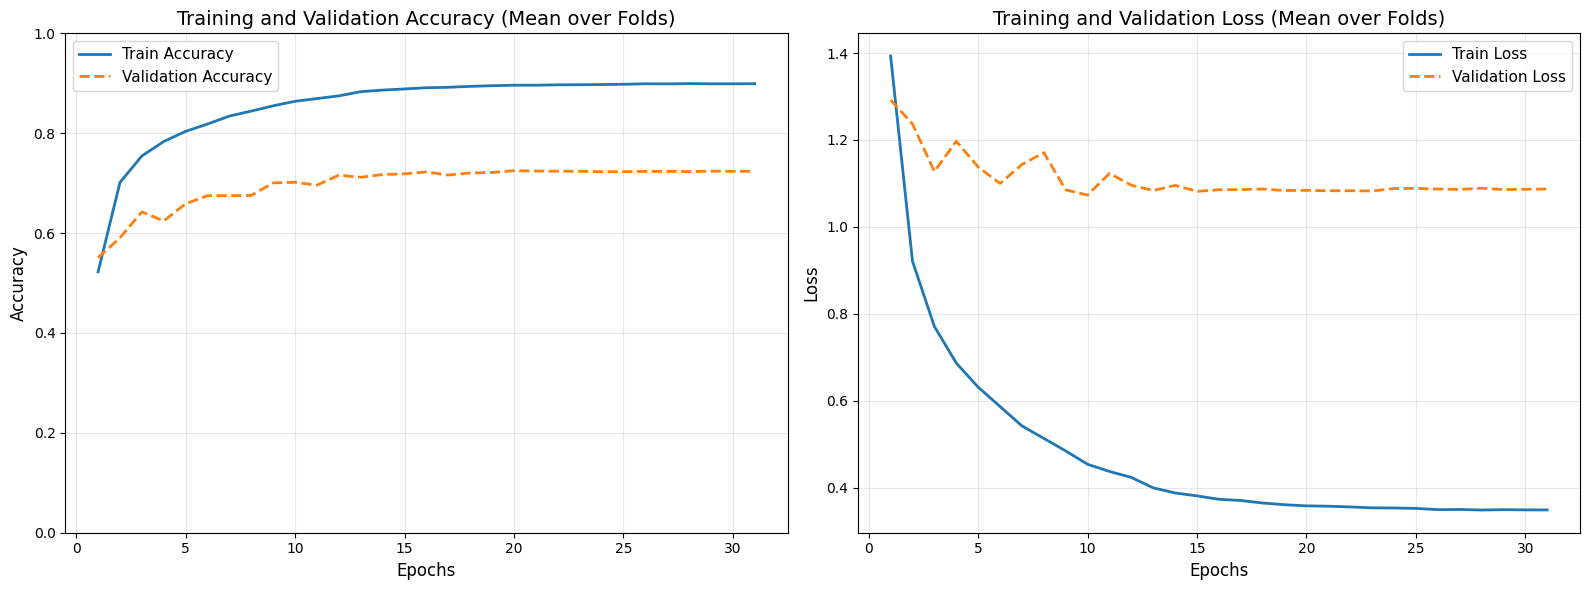

In [11]:
max_epochs = max(len(h["accuracy"]) for h in fold_histories)

def pad(seq, max_len):
    return seq + [seq[-1]] * (max_len - len(seq))

acc_matrix = np.array([pad(h["accuracy"], max_epochs) for h in fold_histories])
val_acc_matrix = np.array([pad(h["val_accuracy"], max_epochs) for h in fold_histories])
loss_matrix = np.array([pad(h["loss"], max_epochs) for h in fold_histories])
val_loss_matrix = np.array([pad(h["val_loss"], max_epochs) for h in fold_histories])

mean_acc_curve = np.mean(acc_matrix, axis=0)
mean_val_acc_curve = np.mean(val_acc_matrix, axis=0)
mean_loss_curve = np.mean(loss_matrix, axis=0)
mean_val_loss_curve = np.mean(val_loss_matrix, axis=0)

epoch_axis = np.arange(1, max_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epoch_axis, mean_acc_curve, label="Train Accuracy", linewidth=2)
ax1.plot(epoch_axis, mean_val_acc_curve, label="Validation Accuracy", linestyle="--", linewidth=2)
ax1.set_title("Training and Validation Accuracy (Mean over Folds)", fontsize=14)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_ylim(0.0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

ax2.plot(epoch_axis, mean_loss_curve, label="Train Loss", linewidth=2)
ax2.plot(epoch_axis, mean_val_loss_curve, label="Validation Loss", linestyle="--", linewidth=2)
ax2.set_title("Training and Validation Loss (Mean over Folds)", fontsize=14)
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()
